# **Team 05 | Modellierung von Energiesystemen**

  Mitglieder:
  + Abdulmalek Alhaj Malek (aalhajma)
  + Anne Kölkes (akoelkes)
  + Felix Paul Schneegans (fgschneeg)
  + Joseph Haddad (jhaddad)
  + Julian Lemmerz (jlemmerz)

**Mitglieder**

| Name | Kürzel | Matrikelnummer |
| :---: | :---: | :---: |
| Abdulmalek Alhaj Malek | aalhajma | 11136361 |
| Anne Kölkes | akoelkes | |
| Felix Paul Schneegans | fschneeg | 11145145 |
| Joseph Haddad | jhaddad | 11221931 |
| Julian Lemmerz | jlemmerz | 11146171 |



### Bibliotheken

In [5]:
import matplotlib as plt
from IPython.display import Image , display
import pypsa as ps
import pandas as pd
import numpy as np

# **Projektvorstellung**

### Fragestellung

Kann die unterbrechungsfreie **Stromversorgung (USV) eines Krankenhauses** auf Basis von **Photovoltaik und Batteriespeicher** genauso oder **wirtschaftlich besser** umgesetzt werden, unter Zuhilfenahme verschiedener Business Cases, im Vergleich zu herkömmlicher USV? 


### Systemskizze

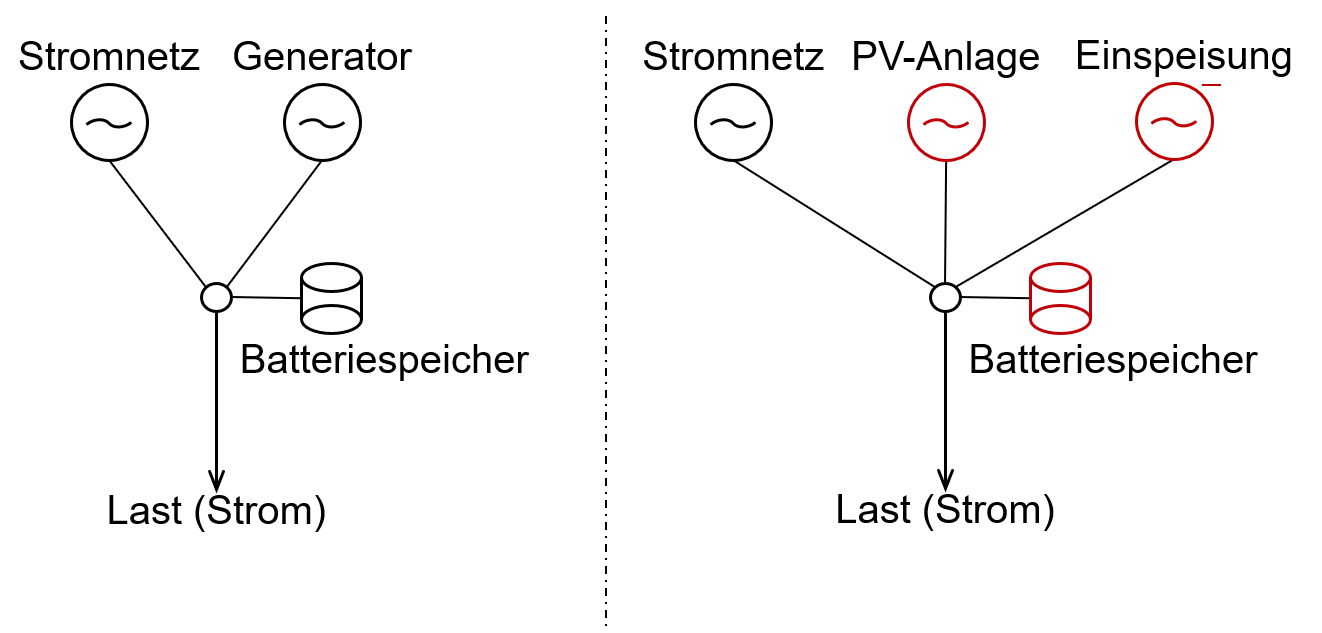

In [ ]:
display(Image(filename="Dateien/Abbildungen/Energiesystem - V1.PNG"))

## Das Krankenhaus

# **Simulation**

### Import Zeitreihen/Last-/Vebrauchsprofile

In [6]:
#Import Lastprofil Strom Krankenhaus
df_loadprofile_krankenhaus = pd.read_csv('Dateien/Stromlastgang_Krankenhaus.csv', sep=';')
Leistung_Strom_Krankenhaus = df_loadprofile_krankenhaus['kW'] # in kW pro 15 min
Verbrauch_Strom_Krankenhaus = df_loadprofile_krankenhaus['kWh'] # in kWh pro 15 min

### Analyse Lastprofil

In [ ]:
print('Maximale Leistung:', Leistung_Strom_Krankenhaus.max(), 'kW')

Maximale Leistung: 600 kW


### Lastgang

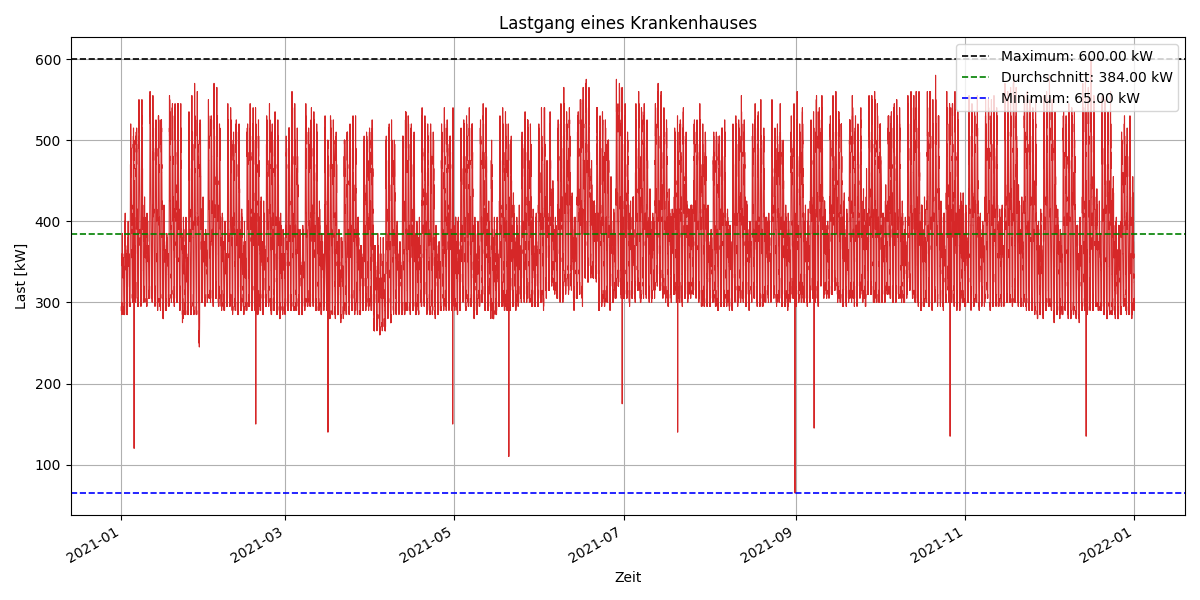

In [31]:
display(Image(filename="Dateien/Abbildungen/Lastgang.png"))

### Heatmap

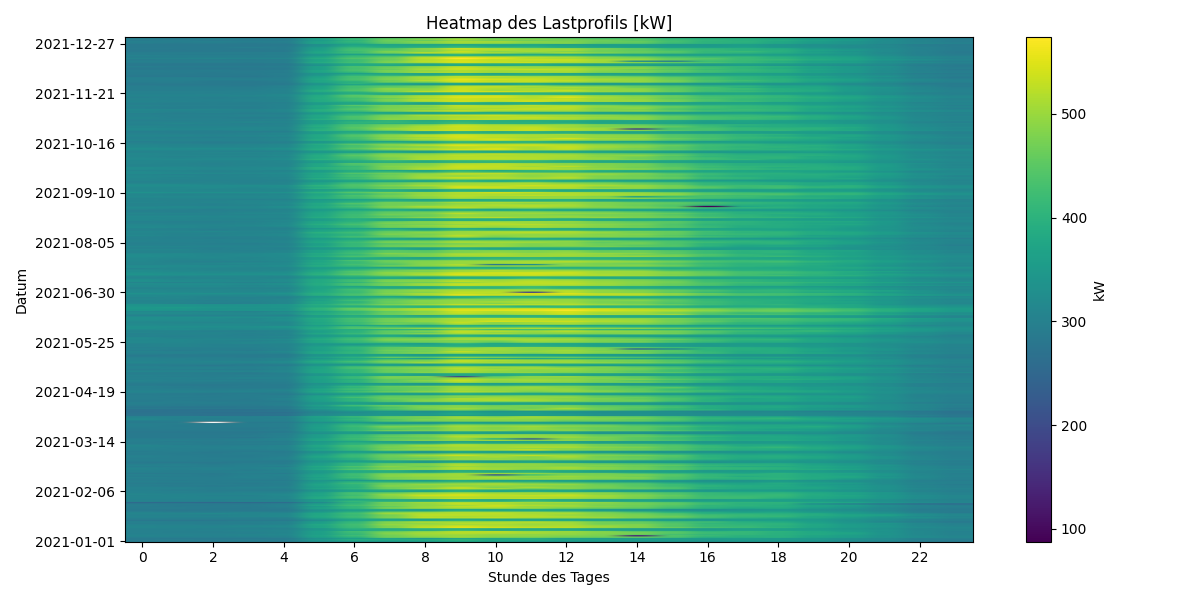

In [32]:
display(Image(filename="Dateien/Abbildungen/Heatmap.png"))

### Parameter


#### Diesel-Generator

In [ ]:
diesel_power = 715 # Leistung in kVA
load_factor = 0.8 # Leistungsfaktor
diesel_rated_power = 572 # Nennleistung in kW
min_load_factor = 0.3 # Minimale Auslastung
min_diesel_power = 172 # Mindestbetriebspunkt in kW
fuel_consumption_full = 146.7 # Verbrauch Volllast in l/h
fuel_consumption_idle_75 = 110 # Verbrauch Teillast (75%) in l/h
fuel_consumption_idle_50 = 76.4 # Verbrauch Teillast (50%) in l/h
startup_time = 0.25 # Startzeit in min
fuel_tank_capacity_epu = 800 # Tankinhalt in l
max_autonomy = 5.5 # Autonomie in h
fuel_storage = 4225 # Treibstoffvorrat in l
fuel_price = 1.712 # Dieselpreis in €/l
capex_diesel = 900 # Investitionskosten in €/kW
opex_diesel = 15444 # Betriebskosten in €/a
lifetime_diesel = 20 # Lebensdauer in a

#### PV

#### Stromnetz

#### Batteriespeicher

### Energiesystem (in Anlehnung an Übung 1)

In [ ]:
#noch zu entfernen, da nicht mehr benötigt
zinssatz = 0.02 # Zinsen in pu
lebensdauer_batterie = 20 # Jahre
roundtrip_eff_batterie = 0.95 # Wikrungsgrad in pu
invest_kosten_batterie = 750 #in Euro 
annuitaet_batterie = invest_kosten_batterie*((1+zinssatz)**lebensdauer_batterie)*zinssatz/((1+zinssatz)**lebensdauer_batterie-1)
p_pv_nom = 5 #kW
einspeiseverguetung = 0.08 #€/kW



In [ ]:
#pyPSA Netzwerk erstellen
network_krankenhaus = pypsa.Network()
network_krankenhaus.set_snapshots(range(35042)) # 35042 Zeitschritte für 15-minütige Daten über ein Jahr



In [ ]:
#PyPSA Netzwerk 
network_pv = pypsa.Network()
network_pv.set_snapshots(range(0,8784)) #Schaltjahr beachten

#Bus
network_pv.add('Bus', name = 'electricity')

#Load
network_pv.add('Load', name = 'elctrical_load', bus = 'electricity', p_set = last)

#Generator
network_pv.add('Generator', name = 'grid_power', bus = 'electricity', p_nom = np.inf, marginal_cost = strompreis)
network_pv.add('Generator', name = 'pv', bus = 'electricity', p_nom = p_pv_nom, p_min_pu=0, p_max_pu=pv_erzeugung/p_pv_nom)
network_pv.add('Generator', name = 'infeed', bus = 'electricity', p_nom = p_pv_nom, min_pu=0, p_max_pu=pv_erzeugung/p_pv_nom, sign=-1 , marginal_cost=-einspeiseverguetung)

#Storage
network_pv.add('StorageUnit', name = 'battery', bus = 'electricity', p_nom_extendable = True, 
            capital_cost = annuitaet_batterie, max_hours = 1, efficiency_store = roundtrip_eff_batterie**0.5,
            efficiency_dispatch = roundtrip_eff_batterie**0.5)

### Netzwerk optimieren

In [ ]:
network_pv.optimize(solver_name = 'gurobi')

C:\Users\felix\AppData\Local\Temp\ipykernel_33712\4234159905.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network_pv.optimize(solver_name = 'gurobi')
Index(['electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 553.19it/s]
INFO:linopy.io: Writing time: 0.25s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2750226


INFO:gurobipy:Set parameter LicenseID to value 2750226


...

Solved in 3731 iterations and 0.74 seconds (0.76 work units)


INFO:gurobipy:Solved in 3731 iterations and 0.74 seconds (0.76 work units)


Optimal objective  3.154747162e+02


INFO:gurobipy:Optimal objective  3.154747162e+02
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52705 primals, 114193 duals
Objective: 3.15e+02
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')